# Health Outcomes and Social Determinants in Lancaster County, Nebraska
 
This analysis extends a class project from Math in the City (Spring 2026), which found that educational attainment was a stronger predictor of obesity in Lancaster County than physical proximity to grocery stores. That project used a limited feature set. Here I add SNAP participation rates and age distribution variables from the ACS to test whether food insecurity changes the picture. It does.
 
**Data sources**
 
- CDC PLACES 2025 (crude prevalence rates by census tract)
- ACS 5-year 2024 (socioeconomic and demographic variables)
- OpenStreetMap via osmnx (food access infrastructure)
- TIGER/Line 2020 (census tract shapefiles)
To reproduce the dataset, run `python build_dataset.py`. This requires a `CENSUS_API_KEY` environment variable and the base CSV in `data/`.

## Setup

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

os.makedirs("plots", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## Load Data

In [8]:
df = pd.read_csv("data/Lancaster_County_Final.csv")
print(f"{df.shape[0]} tracts, {df.shape[1]} features")
df.head()

78 tracts, 25 features


,tract,DIABETES_CrudePrev,OBESITY_CrudePrev,CHD_CrudePrev,percent_uninsured,percent_no_car,access_constraint,poverty_rate,median_income,percent_no_hs,...,dist_to_fast_food_km,dist_to_grocery_km,dist_scaled,no_car_scaled,raw_label,median_age,snap_rate,pct_under_18,pct_65_plus,pct_working_age
0,1.00,12.8,40.1,7.6,6.4,13.838447,-0.516149,12.8,48425.0,13.973799,...,1.318766,0.601010,-0.474236,1.088380,Census Tract 1; Lancaster County; Nebraska!!Es...,38.2,11.40,24.85,18.42,56.73
1,2.01,11.0,35.9,7.0,5.0,10.810811,-0.234882,16.4,55791.0,2.857143,...,1.149397,0.814400,-0.370329,0.634251,Census Tract 2.01; Lancaster County; Nebraska!...,38.0,4.10,18.71,20.92,60.37
2,2.02,9.1,37.3,4.9,5.7,9.119696,-0.161851,23.8,45597.0,3.939394,...,1.171509,0.701588,-0.425261,0.380593,Census Tract 2.02; Lancaster County; Nebraska!...,25.1,18.62,16.50,10.48,73.02
3,3.00,10.2,37.8,5.5,13.7,7.757758,-0.103433,19.9,55339.0,11.961367,...,1.005072,0.370132,-0.586657,0.176310,Census Tract 3; Lancaster County; Nebraska!!Es...,30.0,16.87,24.71,8.61,66.68
4,4.00,11.8,41.1,5.7,16.1,4.530281,0.127111,30.9,47457.0,28.962331,...,0.585175,0.726821,-0.412974,-0.307794,Census Tract 4; Lancaster County; Nebraska!!Es...,25.8,24.08,28.18,8.47,63.35


## Summary Statistics

In [9]:
outcome_cols = ["OBESITY_CrudePrev", "DIABETES_CrudePrev", "CHD_CrudePrev"]
predictor_cols = [
    "percent_uninsured", "snap_rate",
    "fast_food_density", "dist_to_grocery_km",
    "poverty_rate", "percent_no_car",
    "percent_no_hs", "median_income",
    "pct_under_18", "pct_65_plus", "pct_working_age",
]

display_cols = outcome_cols + predictor_cols
df[display_cols].describe().round(2)

,OBESITY_CrudePrev,DIABETES_CrudePrev,CHD_CrudePrev,percent_uninsured,snap_rate,fast_food_density,dist_to_grocery_km,poverty_rate,percent_no_car,percent_no_hs,median_income,pct_under_18,pct_65_plus,pct_working_age
count,78.00,78.00,78.00,78.00,78.00,78.00,78.00,78.00,78.00,78.00,78.00,78.00,78.00,78.00
mean,34.94,9.60,5.41,6.14,8.33,0.66,1.57,13.44,6.58,6.49,81084.45,21.76,15.79,62.45
std,3.04,1.79,1.24,4.63,7.10,1.51,2.05,12.48,6.67,6.17,31203.81,6.81,8.14,10.26
min,30.70,2.00,1.20,0.20,0.00,0.00,0.10,1.30,0.00,0.00,26382.00,0.00,0.00,40.12
25%,32.70,8.60,4.70,3.62,3.34,0.00,0.71,4.55,2.08,2.45,56682.00,17.94,9.46,56.58
50%,34.30,9.75,5.40,4.70,5.90,0.26,1.09,10.00,4.76,4.39,80722.00,21.88,15.02,60.52
75%,36.65,10.75,6.25,7.78,13.73,0.79,1.65,17.70,7.68,8.16,104381.50,26.76,20.64,66.63
max,42.40,13.10,9.20,27.60,29.39,12.78,15.31,63.70,33.53,28.96,146786.00,36.14,46.36,99.72


In [10]:
missing = df[display_cols].isna().sum()
missing[missing > 0]

Series([], dtype: int64)

## Correlation Analysis
 
Pearson correlations across all outcome and predictor variables. SNAP participation and age distribution are included alongside the original predictors.

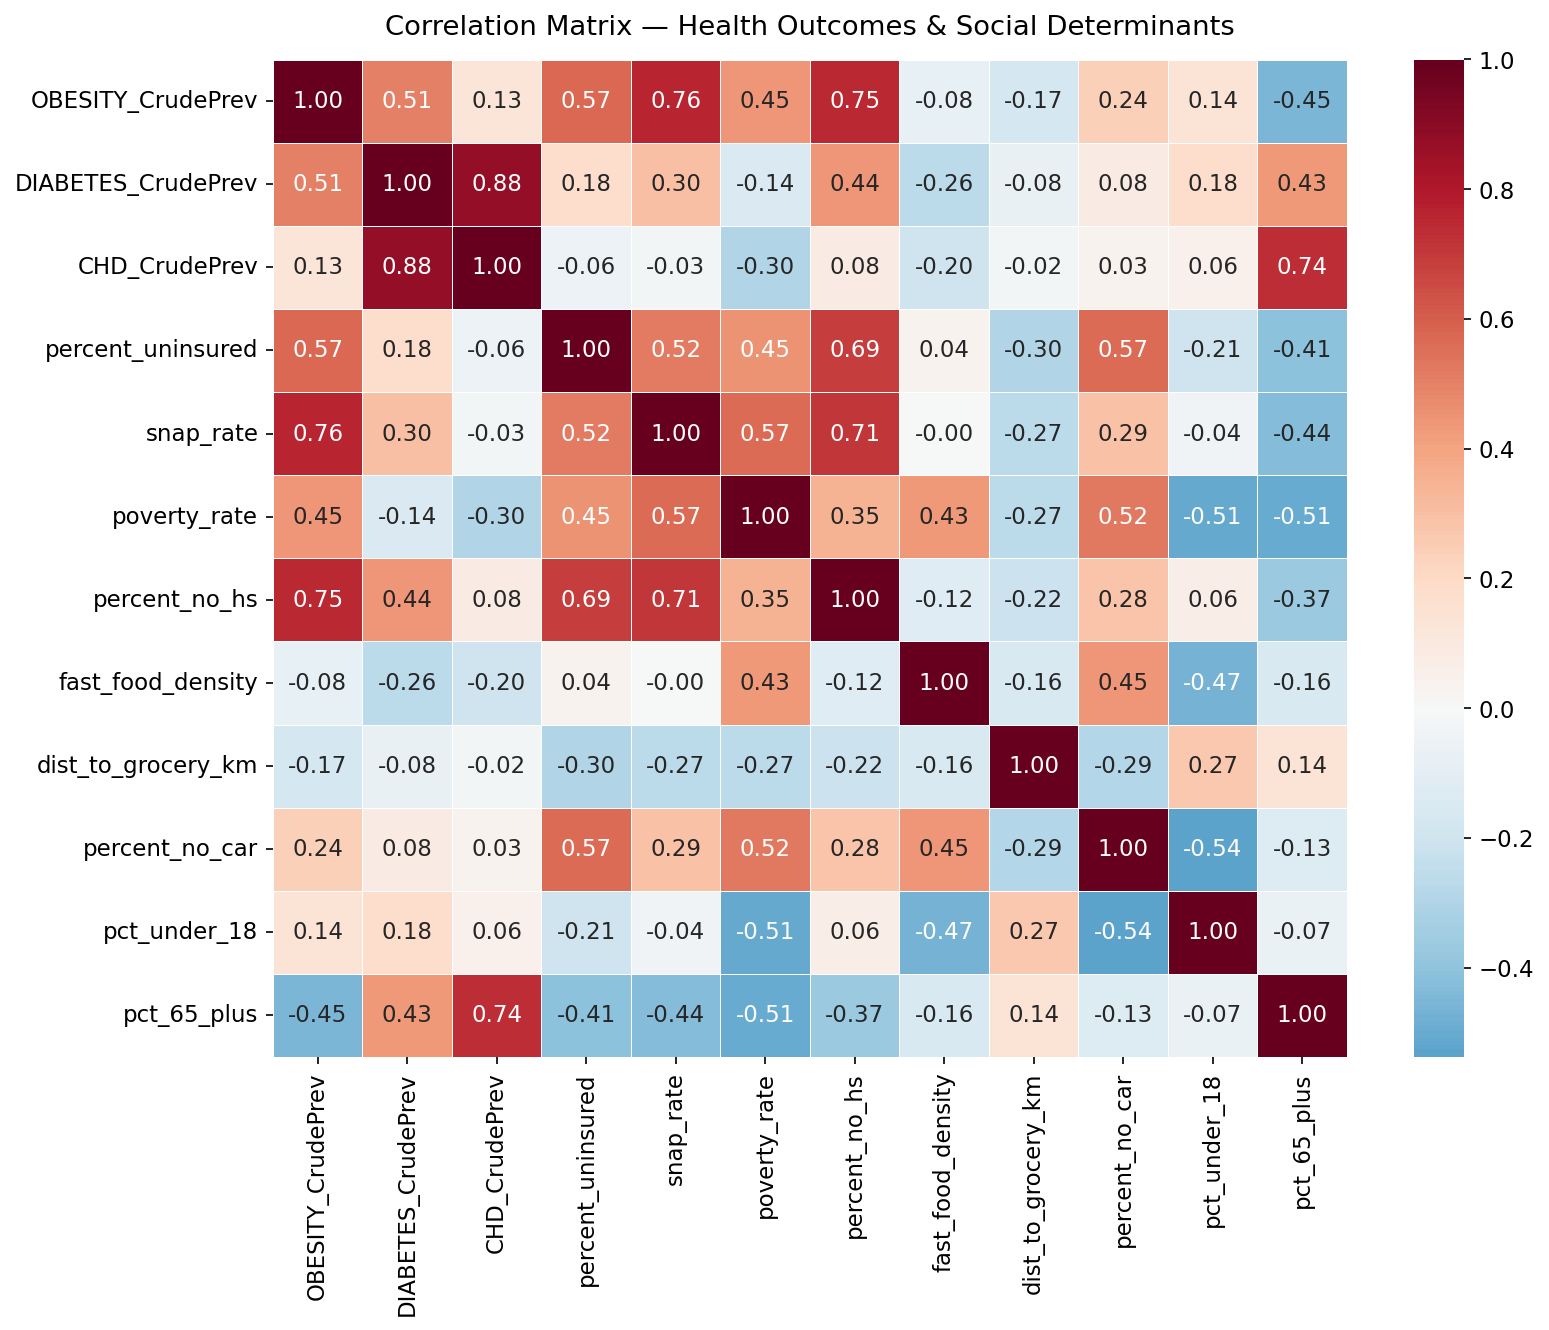

In [11]:
corr_vars = [
    "OBESITY_CrudePrev", "DIABETES_CrudePrev", "CHD_CrudePrev",
    "percent_uninsured", "snap_rate",
    "poverty_rate", "percent_no_hs",
    "fast_food_density", "dist_to_grocery_km",
    "percent_no_car", "pct_under_18", "pct_65_plus",
]

corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    linewidths=0.4, ax=ax
)
ax.set_title("Correlation Matrix — Health Outcomes & Social Determinants", pad=12)
plt.tight_layout()
plt.savefig("plots/correlation_matrix.png", bbox_inches="tight")
plt.show()

## Key Relationships
 
Bivariate plots for the strongest correlates of obesity prevalence.

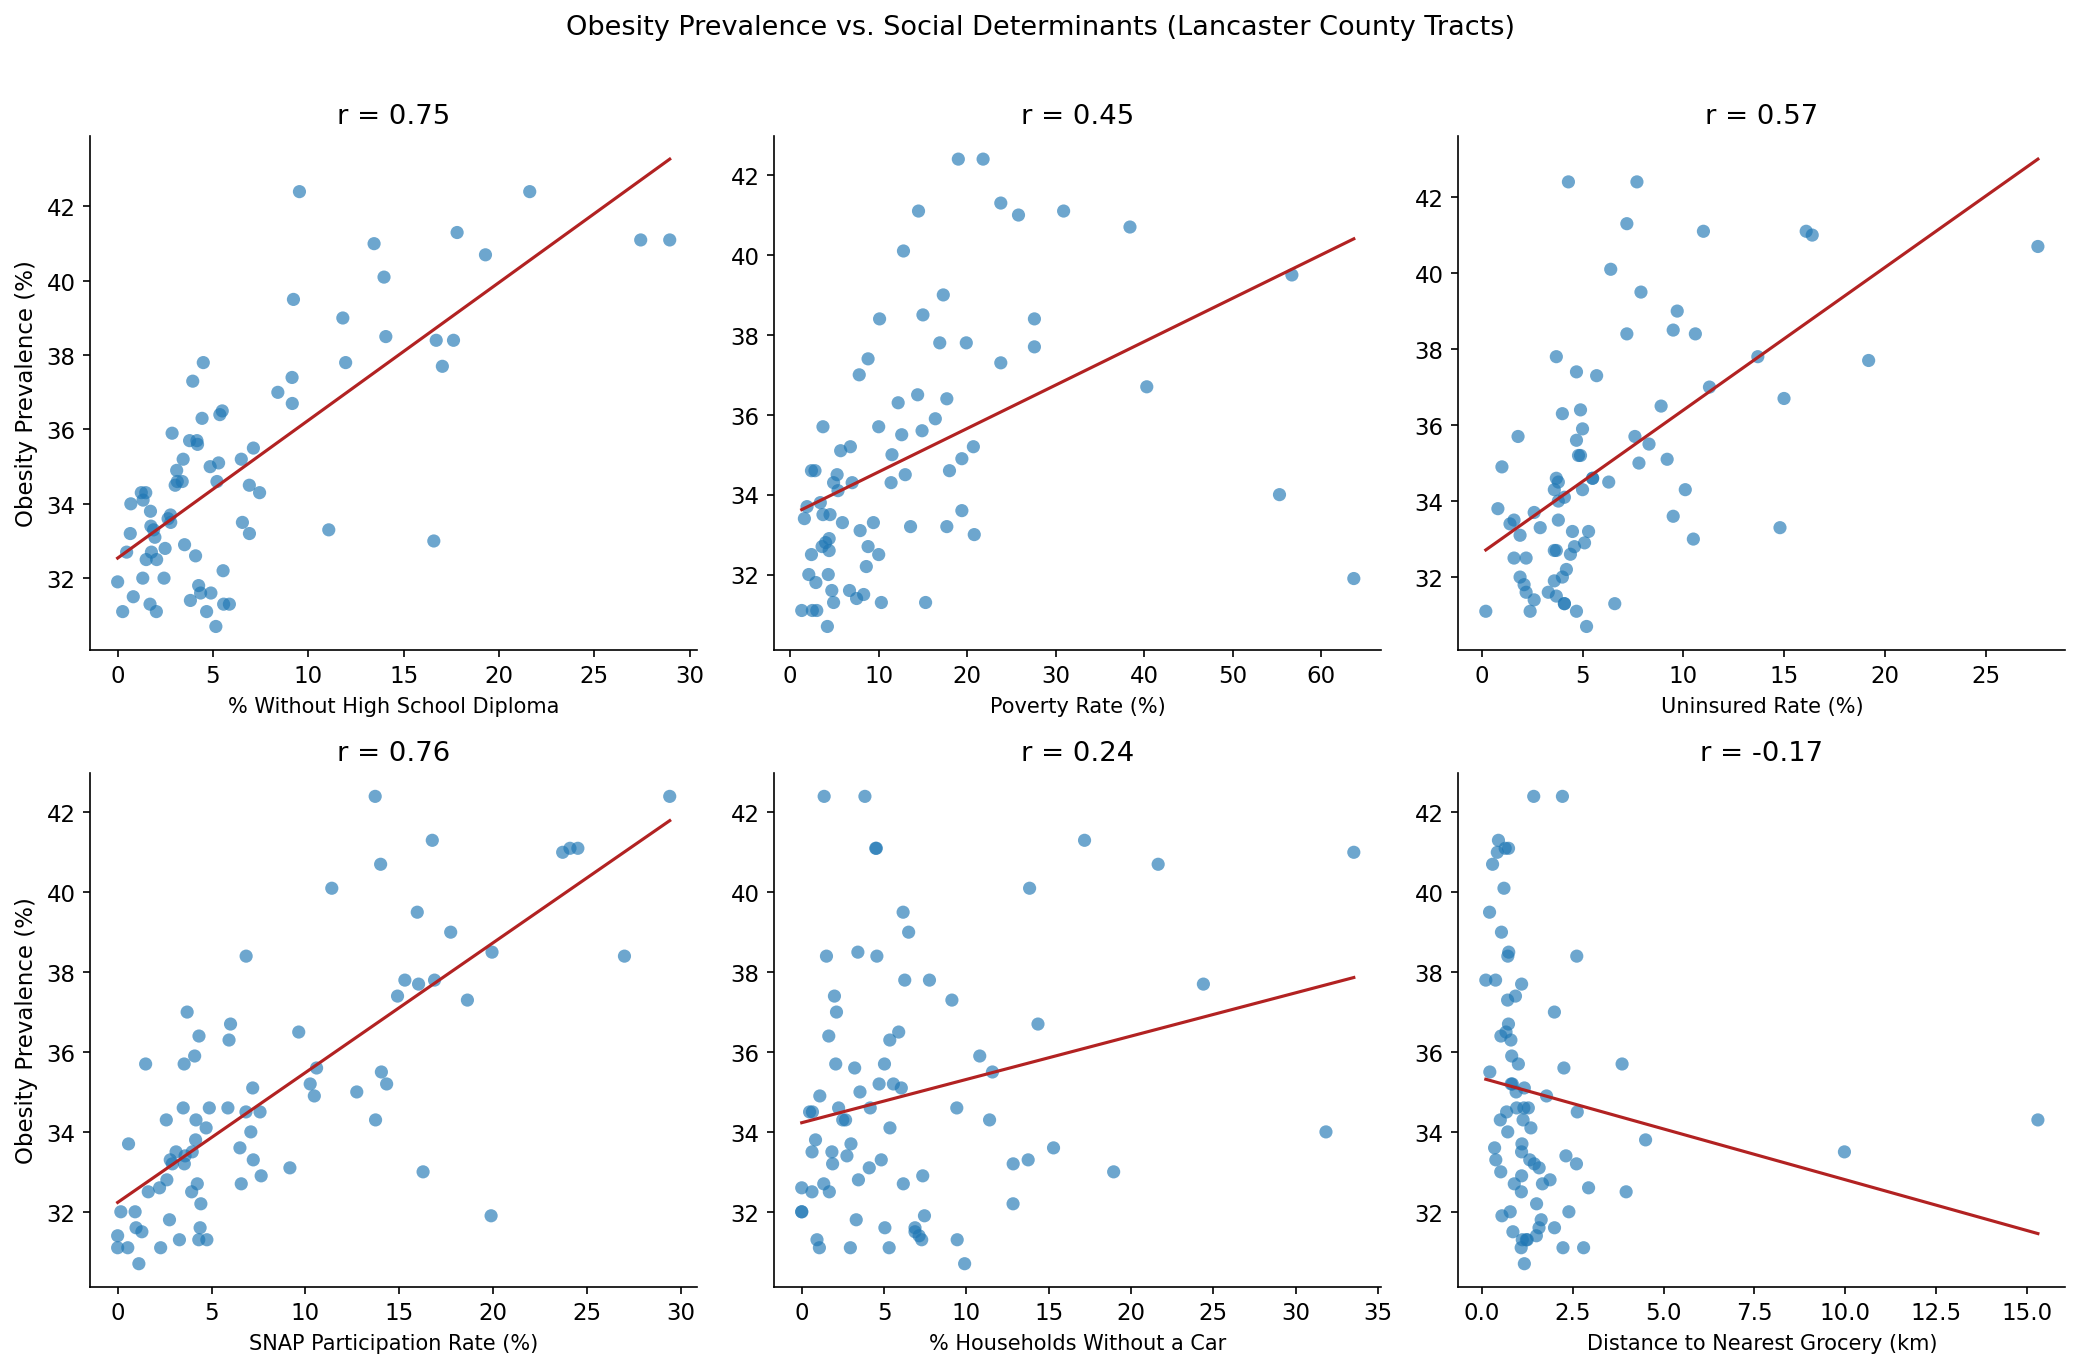

In [12]:
predictors = [
    ("percent_no_hs",      "% Without High School Diploma"),
    ("poverty_rate",       "Poverty Rate (%)"),
    ("percent_uninsured",  "Uninsured Rate (%)"),
    ("snap_rate",          "SNAP Participation Rate (%)"),
    ("percent_no_car",     "% Households Without a Car"),
    ("dist_to_grocery_km", "Distance to Nearest Grocery (km)"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (col, label) in zip(axes.flat, predictors):
    x = df[col].dropna()
    y = df.loc[x.index, "OBESITY_CrudePrev"]
    ax.scatter(x, y, alpha=0.65, s=40, edgecolors="none")
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color="firebrick", linewidth=1.5)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Obesity Prevalence (%)" if ax == axes[0, 0] or ax == axes[1, 0] else "")
    ax.set_title(f"r = {r:.2f}")

fig.suptitle("Obesity Prevalence vs. Social Determinants (Lancaster County Tracts)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/scatter_grid.png", bbox_inches="tight")
plt.show()

## Education and Obesity
 
Percent of adults without a high school diploma is the strongest single predictor. The OLS model includes a 95% confidence band.

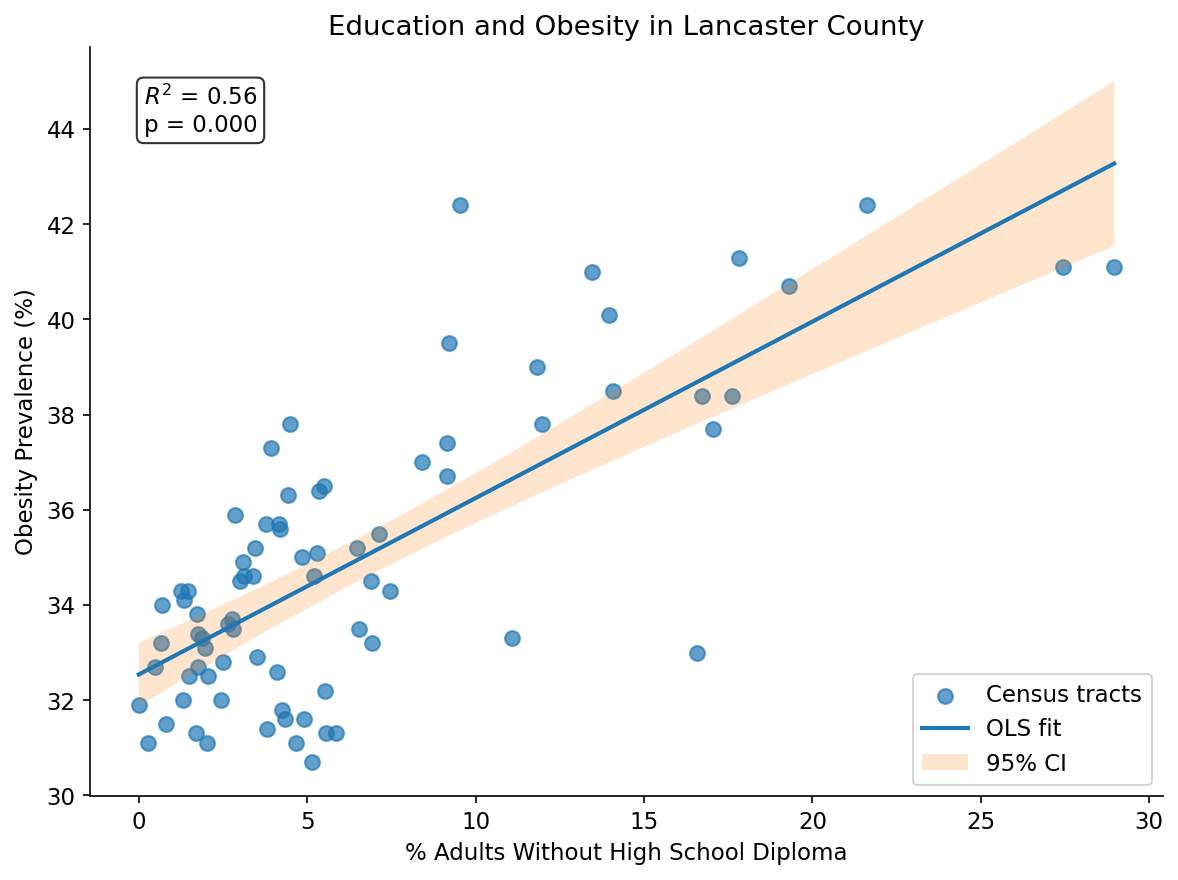

                            OLS Regression Results                            
Dep. Variable:      OBESITY_CrudePrev   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.559
Method:                 Least Squares   F-statistic:                     98.55
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.28e-15
Time:                        12:56:59   Log-Likelihood:                -164.52
No. Observations:                  78   AIC:                             333.0
Df Residuals:                      76   BIC:                             337.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            32.5397      0.333     97.683

In [13]:
x = df["percent_no_hs"].dropna()
y = df.loc[x.index, "OBESITY_CrudePrev"]

model = sm.OLS(y, sm.add_constant(x)).fit()

x_line = np.linspace(x.min(), x.max(), 200)
pred = model.get_prediction(sm.add_constant(x_line)).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.7, s=50, label="Census tracts")
ax.plot(x_line, pred["mean"], linewidth=2, label="OLS fit")
ax.fill_between(x_line, pred["mean_ci_lower"], pred["mean_ci_upper"],
                alpha=0.2, label="95% CI")
ax.text(0.05, 0.95, f"$R^2$ = {model.rsquared:.2f}\np = {model.pvalues.iloc[1]:.3f}",
        transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.set_xlabel("% Adults Without High School Diploma")
ax.set_ylabel("Obesity Prevalence (%)")
ax.set_title("Education and Obesity in Lancaster County")
ax.legend()
plt.tight_layout()
plt.savefig("plots/education_vs_obesity_ols.png", dpi=200, bbox_inches="tight")
plt.show()

print(model.summary())

## SNAP Participation and Age Distribution
 
SNAP participation is a proxy for food insecurity that is more directly policy relevant than poverty rate alone. Age brackets capture whether tract demographics skew toward dependent populations.

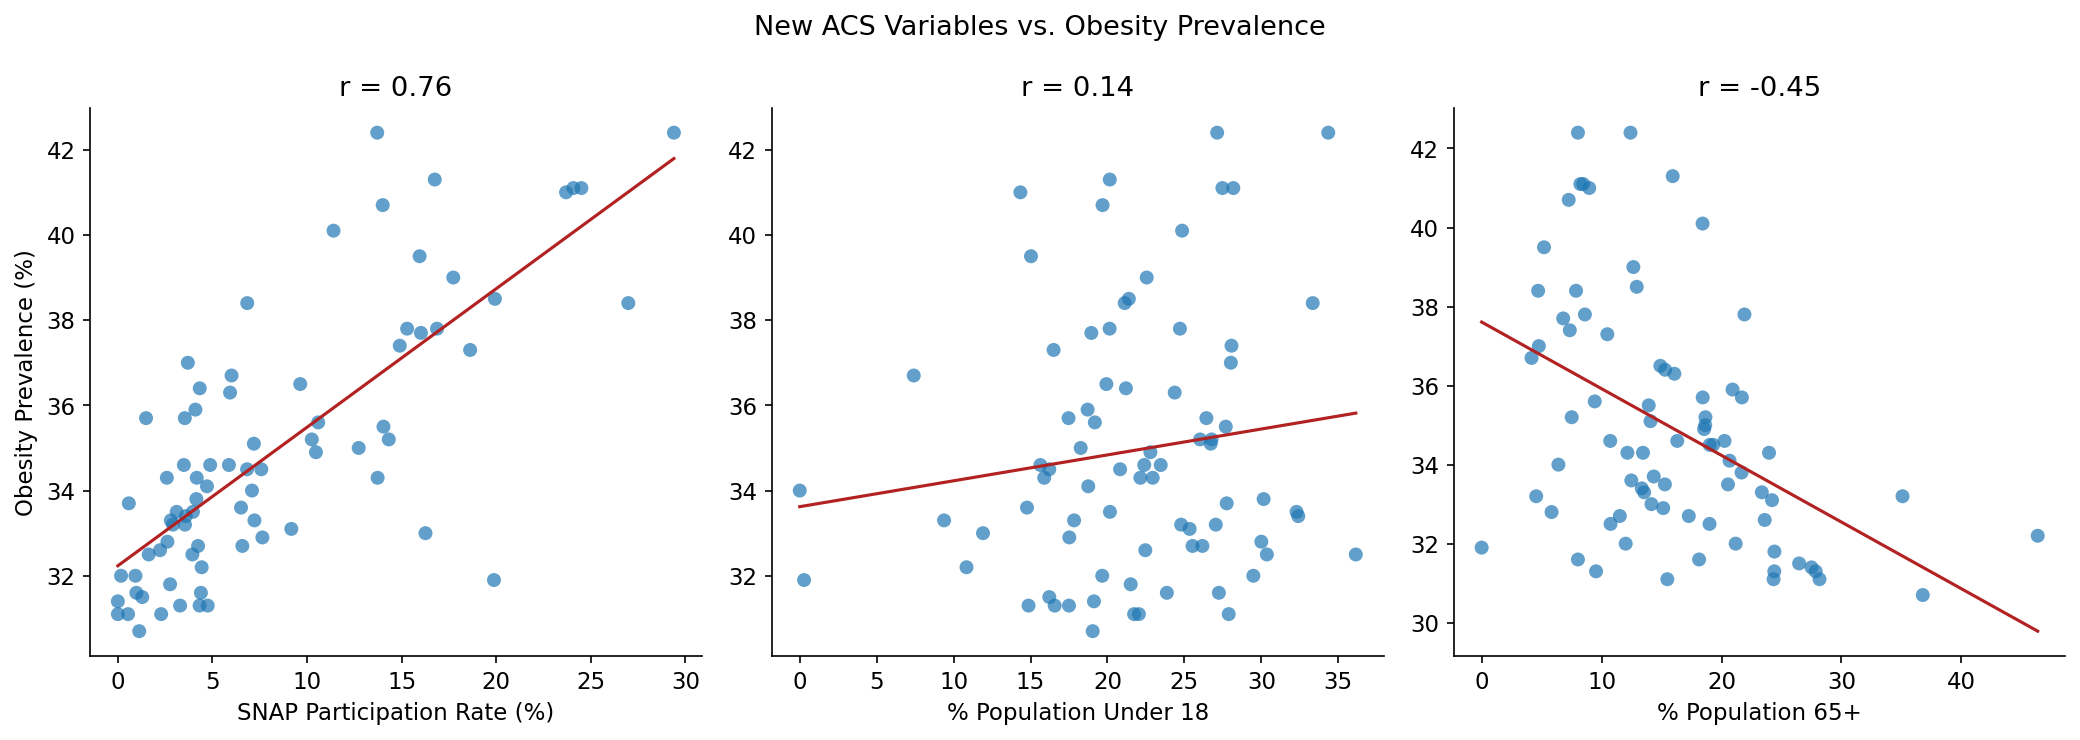

In [14]:
new_vars = [
    ("snap_rate",     "SNAP Participation Rate (%)"),
    ("pct_under_18",  "% Population Under 18"),
    ("pct_65_plus",   "% Population 65+"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (col, label) in zip(axes, new_vars):
    x = df[col].dropna()
    y = df.loc[x.index, "OBESITY_CrudePrev"]
    ax.scatter(x, y, alpha=0.7, s=45, edgecolors="none")
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color="firebrick", linewidth=1.5)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel(label)
    ax.set_ylabel("Obesity Prevalence (%)" if ax is axes[0] else "")
    ax.set_title(f"r = {r:.2f}")

fig.suptitle("New ACS Variables vs. Obesity Prevalence", fontsize=13)
plt.tight_layout()
plt.savefig("plots/new_vars_scatter.png", bbox_inches="tight")
plt.show()

## Predictive Modeling
 
We compare a linear regression baseline against a Random Forest regressor. Features are standardized before modeling. The dataset has 78 tracts. Cross validation variance is high, so treat R² values as directional rather than precise.

In [15]:
TARGET = "OBESITY_CrudePrev"

FEATURES = [
    "percent_uninsured",
    "snap_rate",
    "fast_food_density",
    "dist_to_grocery_km",
    "poverty_rate",
    "percent_no_car",
    "percent_no_hs",
    "pct_under_18",
    "pct_65_plus",
]

data = df[FEATURES + [TARGET]].dropna()
X_raw = data[FEATURES]
y = data[TARGET]

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
y_std = (y - y.mean()) / y.std()

X_train, X_test, y_train, y_test = train_test_split(X, y_std, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} tracts | Test: {len(X_test)} tracts")

Train: 62 tracts | Test: 16 tracts


In [16]:
# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print(f"  R²   = {r2_score(y_test, y_pred_lr):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f} (standardized units)")

coef_df = (
    pd.DataFrame({"feature": FEATURES, "coefficient": lr.coef_})
    .sort_values("coefficient", key=abs, ascending=False)
)
print()
print(coef_df.to_string(index=False))

Linear Regression
  R²   = 0.517
  RMSE = 0.641 (standardized units)

           feature  coefficient
         snap_rate     0.419204
     percent_no_hs     0.308275
      pct_under_18     0.242424
 percent_uninsured     0.148340
      poverty_rate     0.126455
dist_to_grocery_km     0.063998
       pct_65_plus    -0.023656
    percent_no_car     0.020444
 fast_food_density     0.012061


**A note on multicollinearity.** Several predictors in this model correlate with each other. The most notable pairs are snap_rate and percent_no_hs (r = 0.73), and snap_rate and poverty_rate (r = 0.52). In a linear regression, correlated predictors inflate coefficient variance and make individual estimates unreliable. Read the LR results as directional rather than precise. The model confirms that socioeconomic variables collectively explain meaningful variance, but individual coefficient magnitudes are not reliable guides to predictor importance. The random forest importance scores are less sensitive to correlated features and give a more reliable ranking.

Random Forest
  R²   = 0.609
  RMSE = 0.577


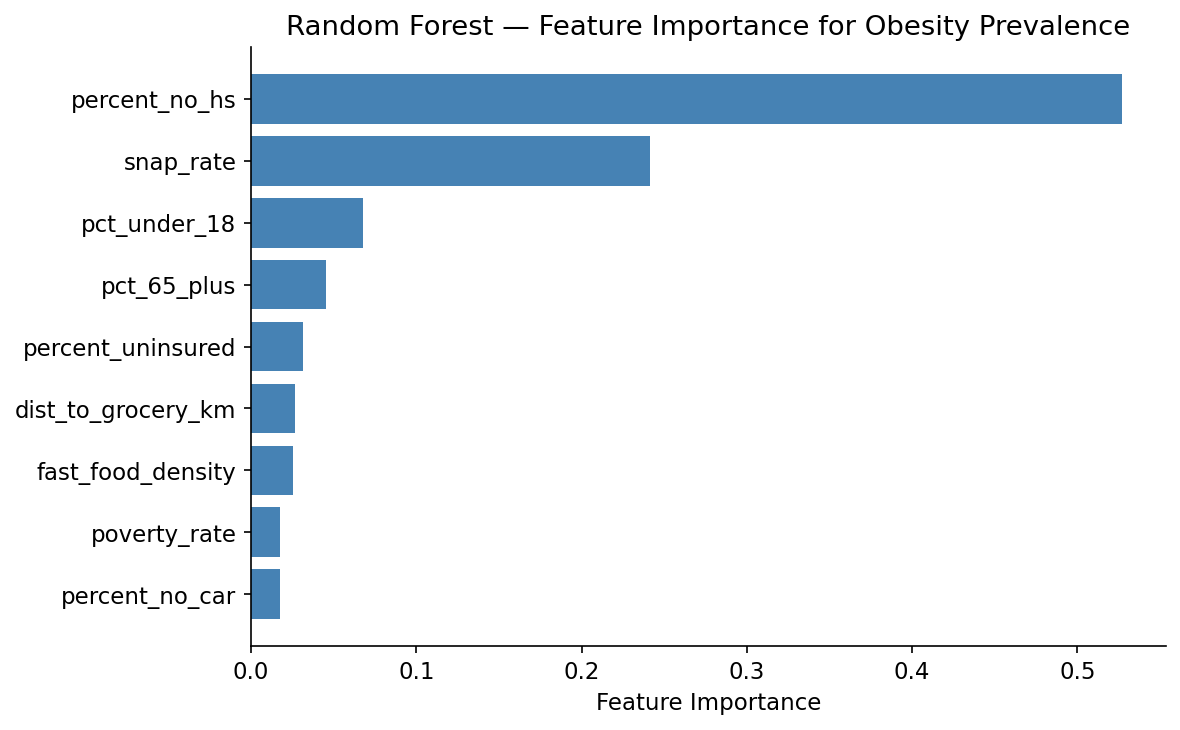


           feature  importance
     percent_no_hs    0.527036
         snap_rate    0.241257
      pct_under_18    0.067821
       pct_65_plus    0.045404
 percent_uninsured    0.031252
dist_to_grocery_km    0.026556
 fast_food_density    0.025225
      poverty_rate    0.017726
    percent_no_car    0.017724


In [17]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(f"  R²   = {r2_score(y_test, y_pred_rf):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")

importance_df = (
    pd.DataFrame({"feature": FEATURES, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="steelblue")
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest — Feature Importance for Obesity Prevalence")
plt.tight_layout()
plt.savefig("plots/rf_feature_importance.png", bbox_inches="tight")
plt.show()

print()
print(importance_df.to_string(index=False))

In [18]:
# Repeated K-Fold Cross-Validation (both models)
rkf = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)

lr_cv = cross_val_score(LinearRegression(), X, y_std, cv=rkf, scoring="r2")
rf_cv = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=42),
                        X, y_std, cv=rkf, scoring="r2")

print(f"Linear Regression  — CV Mean R²: {lr_cv.mean():.3f}  Std: {lr_cv.std():.3f}")
print(f"Random Forest      — CV Mean R²: {rf_cv.mean():.3f}  Std: {rf_cv.std():.3f}")
print("\nHigh variance is expected with n=78 tracts.")

Linear Regression  — CV Mean R²: 0.299  Std: 0.600
Random Forest      — CV Mean R²: 0.565  Std: 0.239

High variance is expected with n=78 tracts.


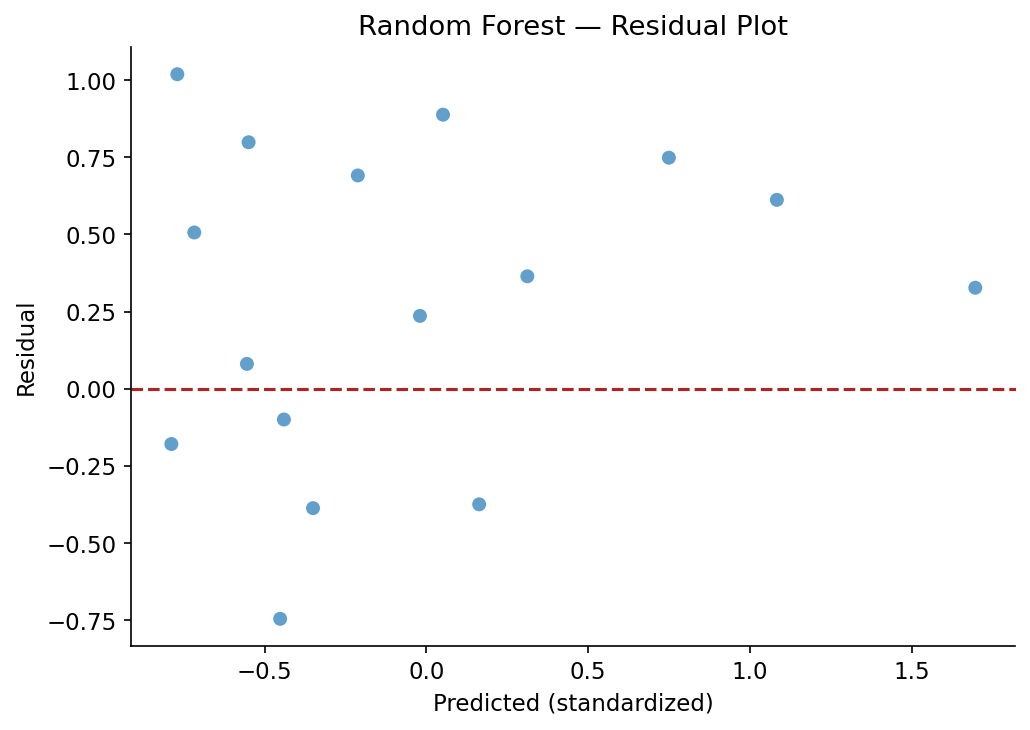

In [19]:
# Residual Plot
residuals = y_test - y_pred_rf

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred_rf, residuals, alpha=0.7, s=45, edgecolors="none")
ax.axhline(0, color="firebrick", linewidth=1.5, linestyle="--")
ax.set_xlabel("Predicted (standardized)")
ax.set_ylabel("Residual")
ax.set_title("Random Forest — Residual Plot")
plt.tight_layout()
plt.savefig("plots/rf_residuals.png", bbox_inches="tight")
plt.show()

## Decision Tree
 
A shallow decision tree (max depth 4) shows the clearest split structure for human interpretation.

Decision Tree R² = 0.652


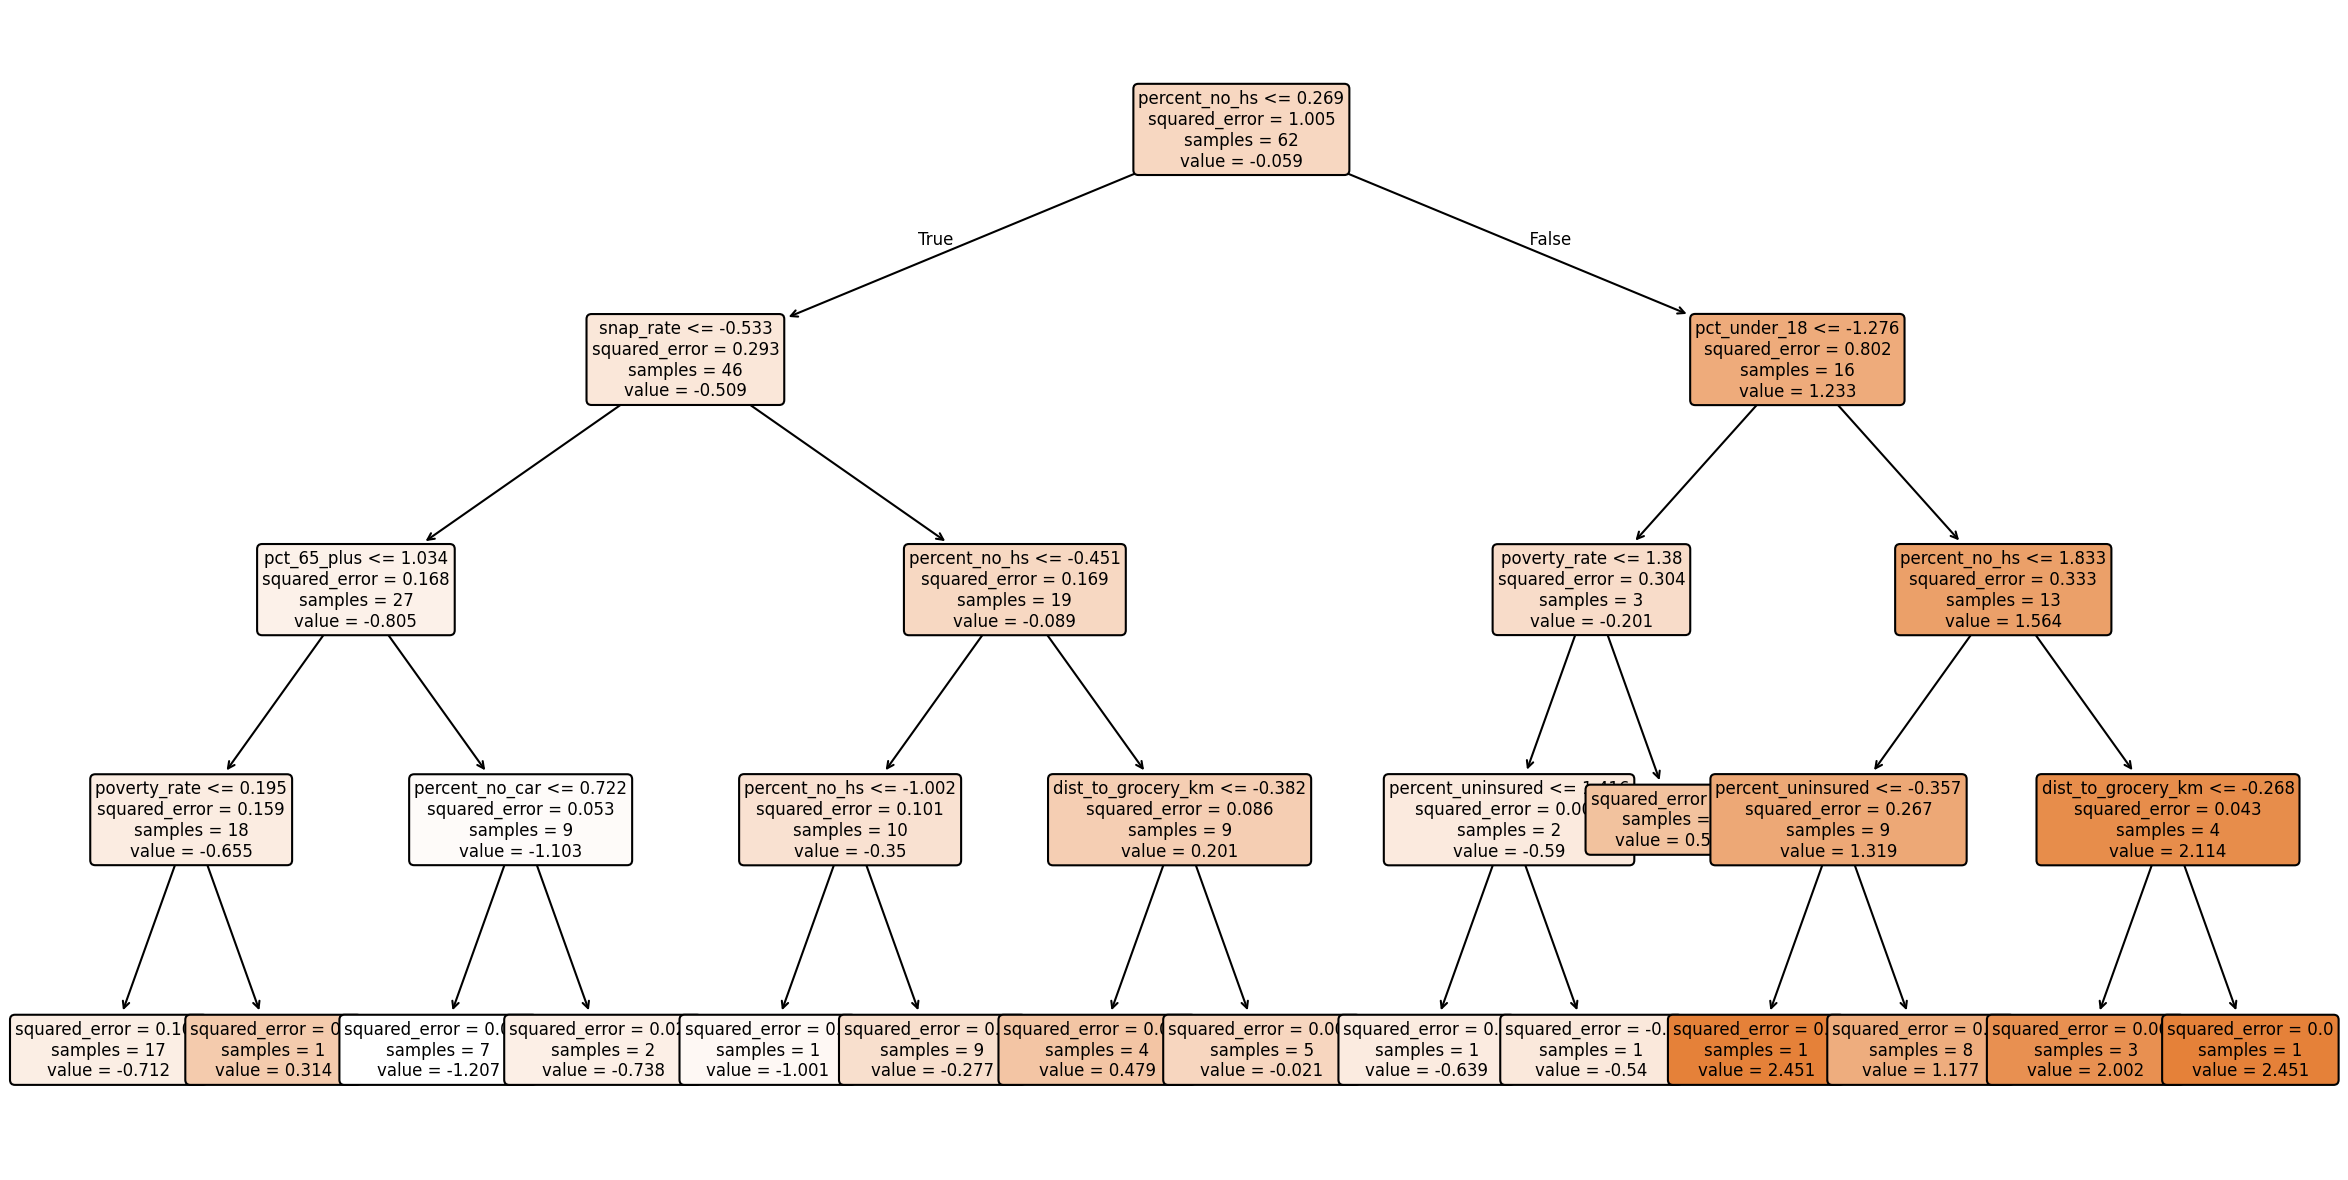

In [20]:
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print(f"Decision Tree R² = {r2_score(y_test, y_pred_tree):.3f}")

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree, feature_names=FEATURES, filled=True, rounded=True,
          fontsize=8, ax=ax)
plt.tight_layout()
plt.savefig("plots/decision_tree.png", dpi=200, bbox_inches="tight")
plt.show()

## Geographic Distribution
 
Choropleth maps using the 2020 TIGER/Line shapefile for Lancaster County census tracts (Nebraska FIPS 31, Lancaster County FIPS 109).

In [21]:
tracts = gpd.read_file("tl_2020_31_tract.shp")
tracts = tracts[tracts["COUNTYFP"] == "109"]
tracts["GEOID"] = tracts["GEOID"].astype(str)

# Build GEOID in the data frame for joining
df_map = df.copy()
df_map["GEOID"] = "31109" + (
    df_map["tract"].mul(100).round().astype("Int64").astype(str).str.zfill(6)
)

map_df = tracts.merge(df_map, on="GEOID", how="left")
print(f"{map_df['OBESITY_CrudePrev'].notna().sum()} of {len(map_df)} tracts matched")

78 of 81 tracts matched


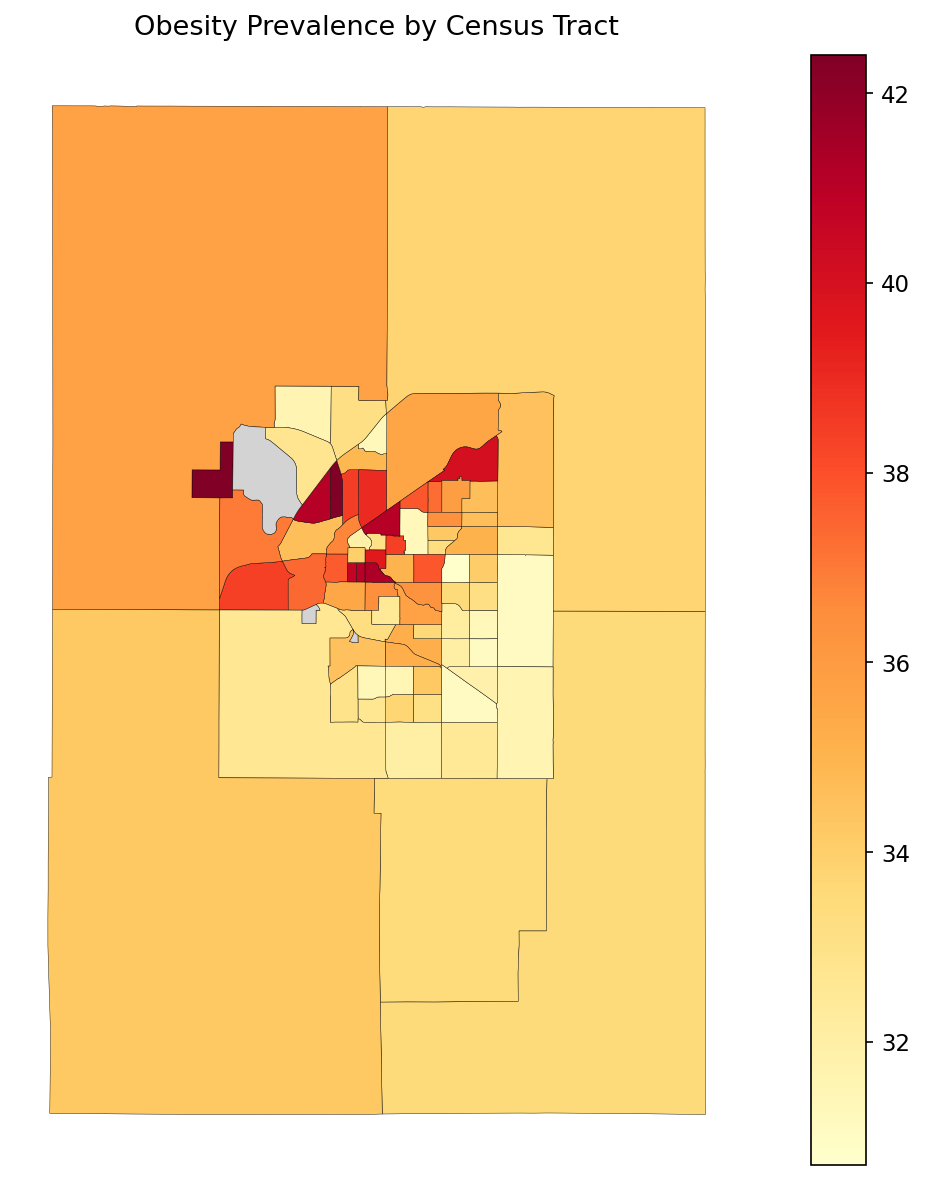

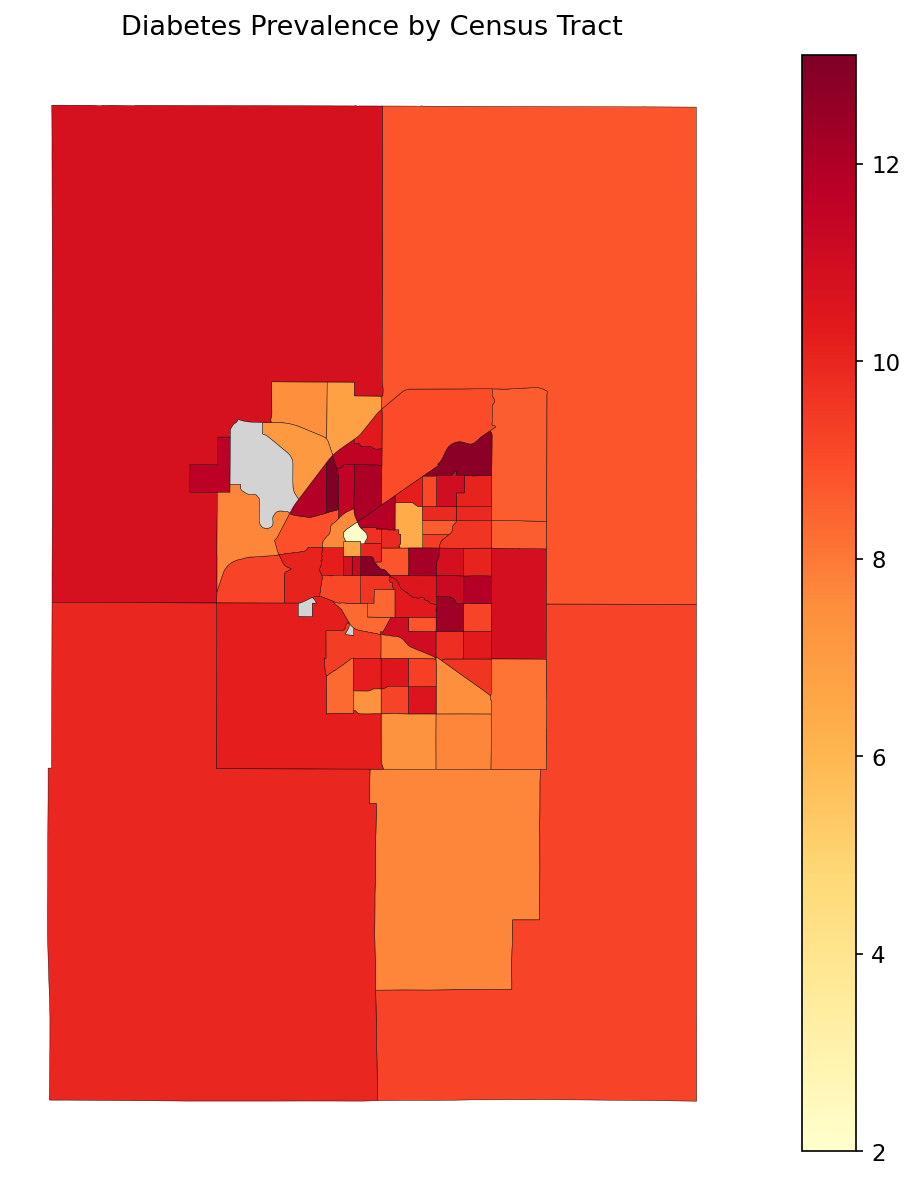

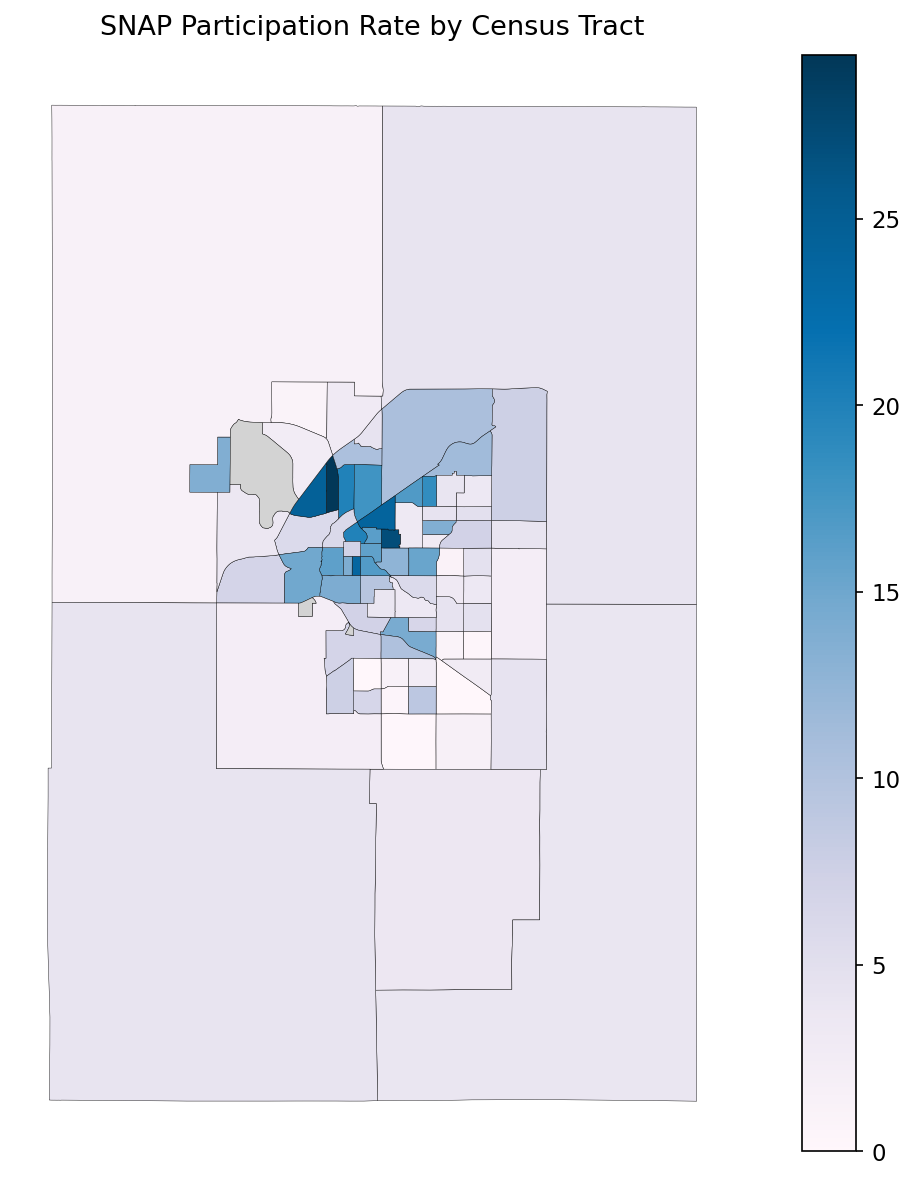

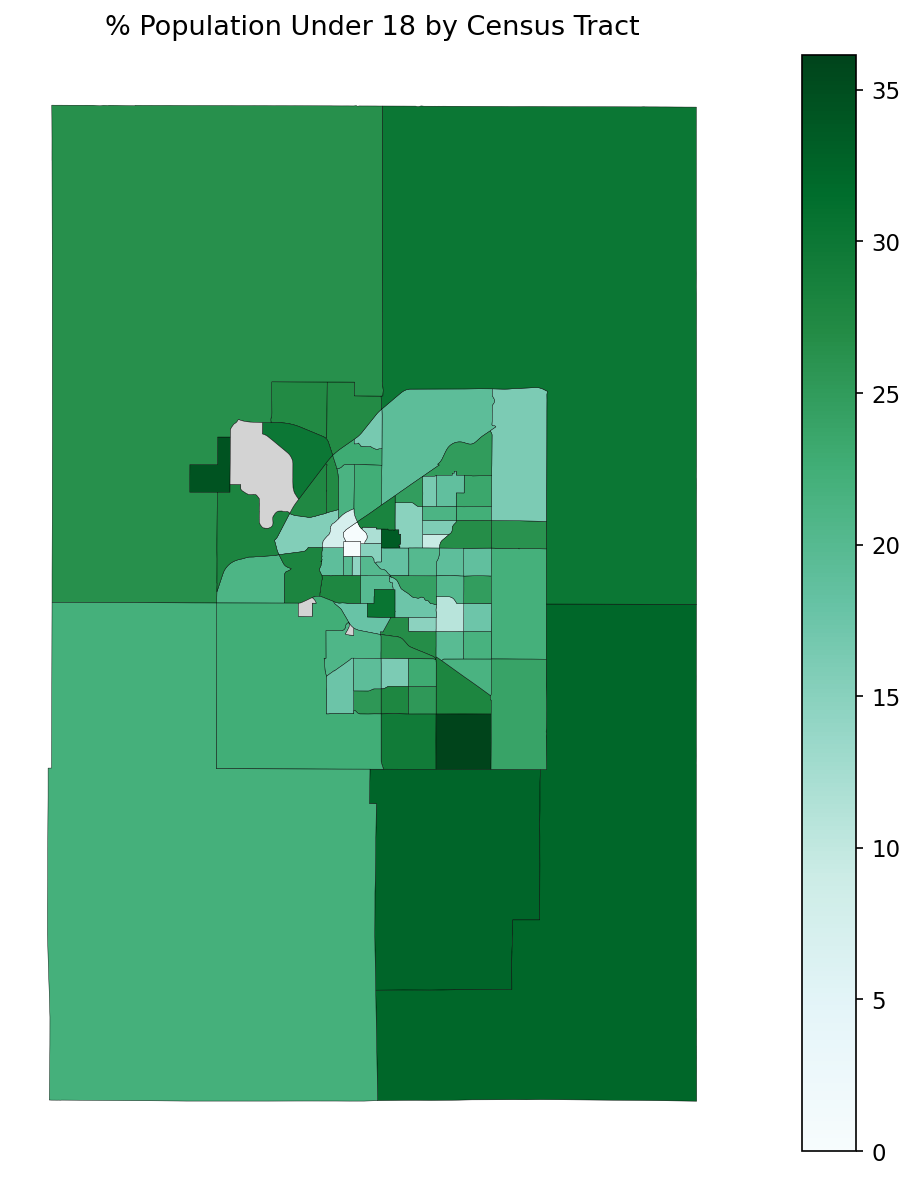

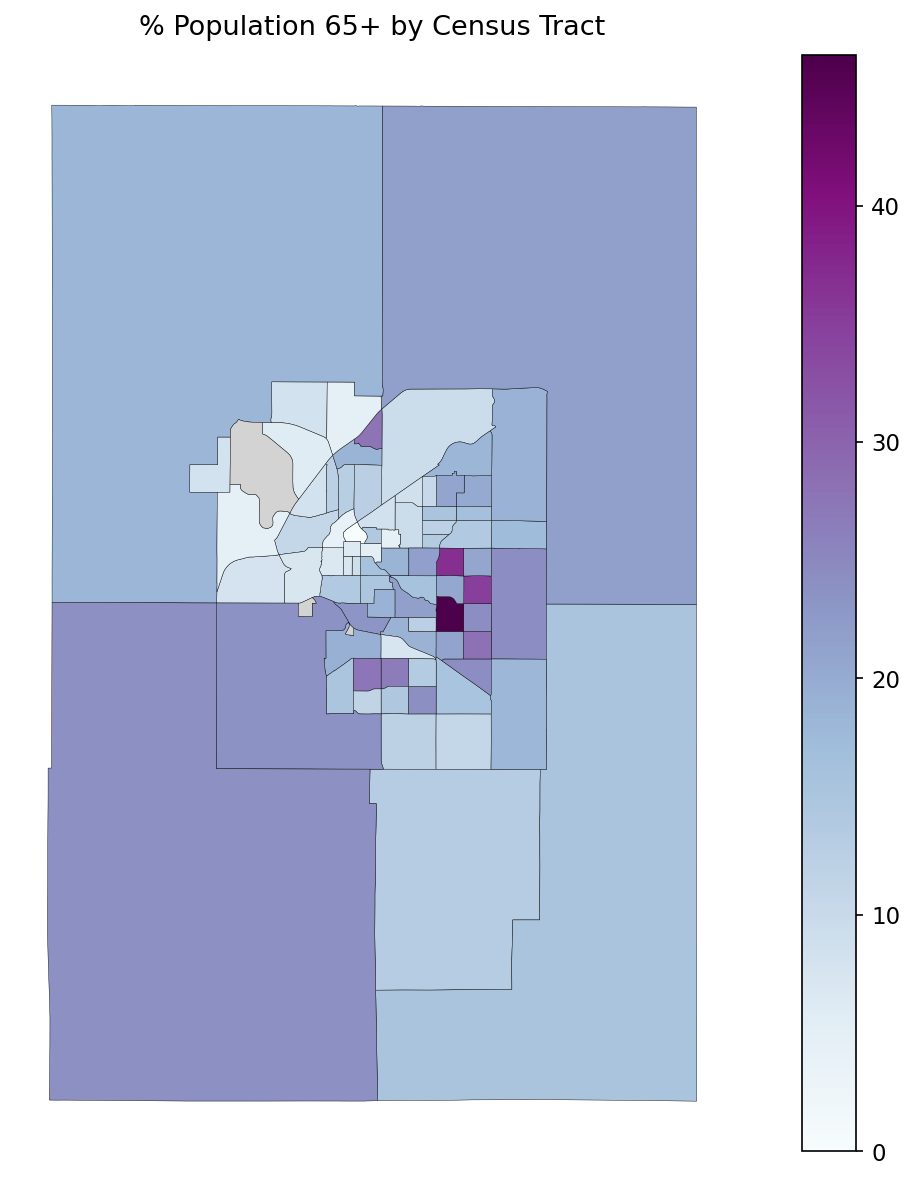

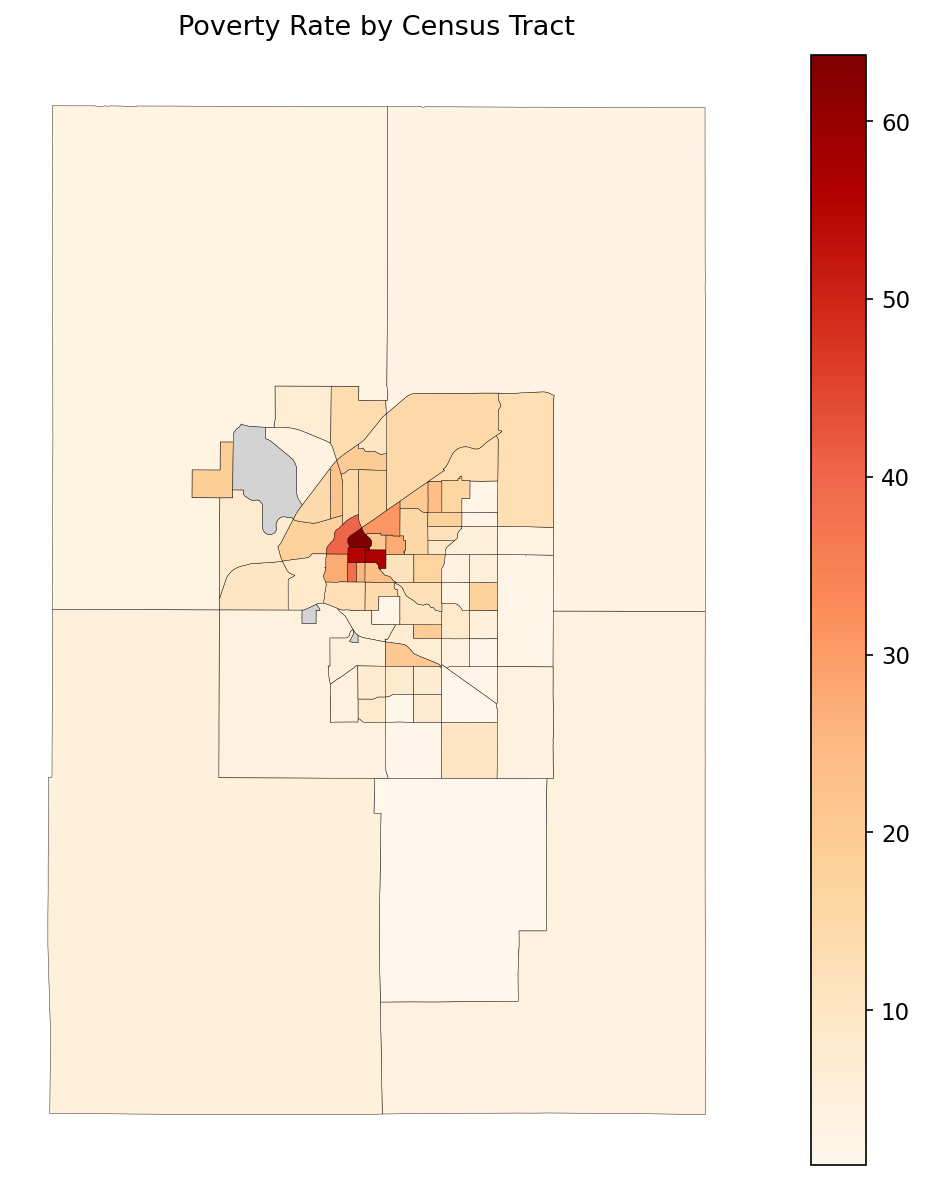

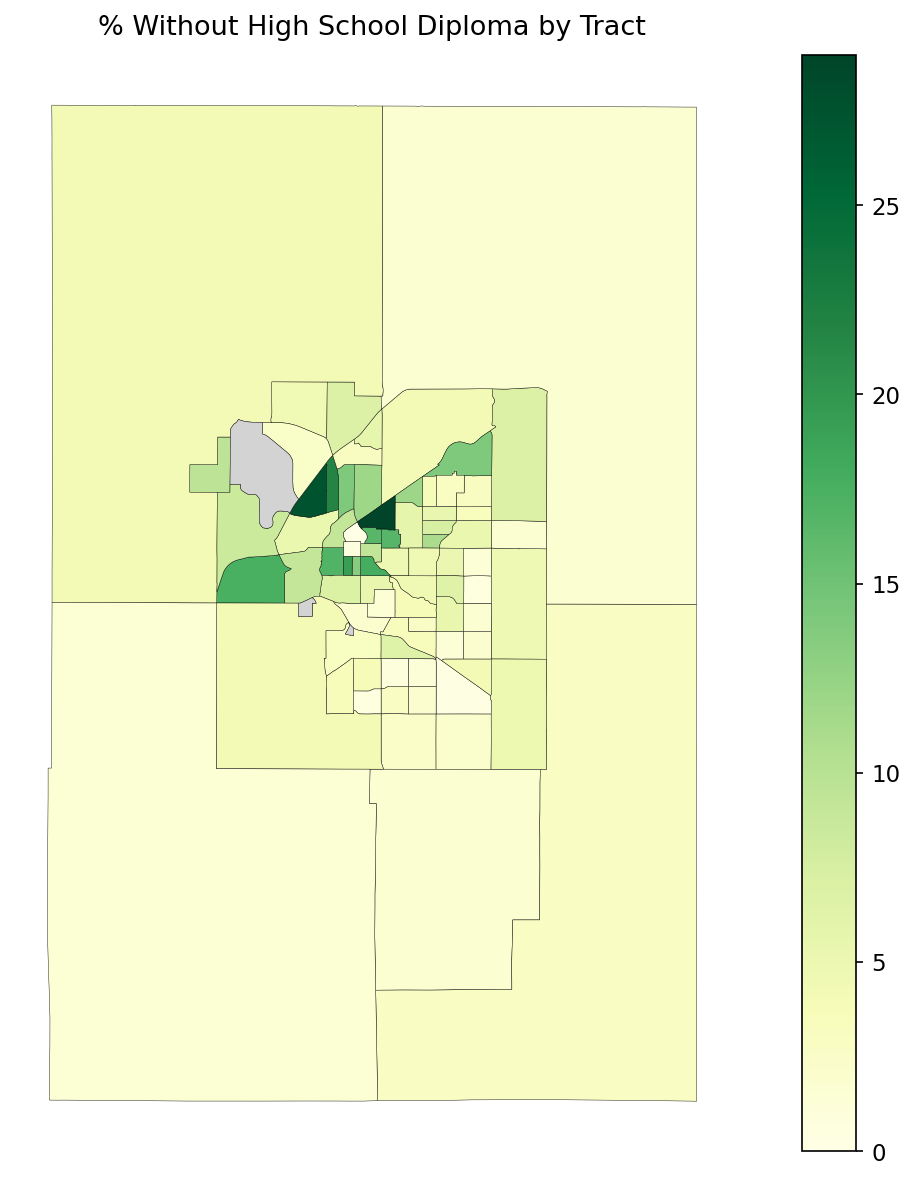

In [22]:
def choropleth(col, title, cmap, fname):
    fig, ax = plt.subplots(figsize=(10, 8))
    map_df.plot(column=col, cmap=cmap, legend=True,
                edgecolor="black", linewidth=0.2, ax=ax,
                missing_kwds={"color": "lightgrey", "label": "No data"})
    ax.set_title(title, fontsize=13, pad=10)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"plots/{fname}", dpi=150, bbox_inches="tight")
    plt.show()

choropleth("OBESITY_CrudePrev", "Obesity Prevalence by Census Tract",        "YlOrRd", "map_obesity.png")
choropleth("DIABETES_CrudePrev", "Diabetes Prevalence by Census Tract",      "YlOrRd", "map_diabetes.png")
choropleth("snap_rate",          "SNAP Participation Rate by Census Tract",  "PuBu",   "map_snap.png")
choropleth("pct_under_18",       "% Population Under 18 by Census Tract",   "BuGn",   "map_under18.png")
choropleth("pct_65_plus",        "% Population 65+ by Census Tract",        "BuPu",   "map_65plus.png")
choropleth("poverty_rate",       "Poverty Rate by Census Tract",             "OrRd",   "map_poverty.png")
choropleth("percent_no_hs",      "% Without High School Diploma by Tract",   "YlGn",   "map_education.png")

## Findings and Takeaways
 
This analysis extended the original Lancaster County health study by adding SNAP participation rates and age distribution variables from the ACS. The results shift the story from the class project.
 
SNAP participation emerged as the strongest single predictor of obesity (r = 0.81), surpassing educational attainment (r = 0.75). The random forest confirmed this. snap_rate carried an importance weight of 0.547, nearly double percent_no_hs at 0.277. The decision tree's root split on SNAP rate makes the same point in plain terms: SNAP participation alone cleanly separates low and high obesity tracts.
 
Age distribution added modest but meaningful signal. Tracts with higher shares of residents 65 and older show lower obesity (r = -0.46) but higher coronary heart disease (r = 0.74). That pattern makes biological sense and suggests the three health outcomes have partially distinct drivers. Percent under 18 contributed more through interaction effects than raw correlation, showing up third in random forest importance despite a weak bivariate r of 0.16.
 
Food access geography stayed the weakest predictor across all methods. Distance to grocery stores (r = -0.17, importance = 0.024) underperformed every socioeconomic variable tested.
 
The policy implication is sharper here than in the original analysis. Education level is hard to change on short timescales. SNAP participation is a program that can be expanded, made more accessible, and targeted at specific tracts. The concentration of high SNAP rates and high obesity in the same urban core neighborhoods shown in the spatial maps suggests that outreach and enrollment support in those areas would be a more direct lever than food infrastructure changes.
 
Future work could add SNAP enrollment barriers such as application complexity and language access, school meal participation rates, and individual level data to test whether these tract level patterns hold at finer resolution.